# Predicciones de cancelaciones de membresias de Gimnasio

La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

Los indicadores de pérdida varían de un campo a otro. Si un usuario o una usuaria compra en una tienda en línea con poca frecuencia, pero con regularidad, no se puede decir que ha huido. Pero si durante dos semanas no ha abierto un canal que se actualiza a diario, es motivo de preocupación: es posible que tu seguidor o seguidor/a se haya aburrido y te haya abandonado.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Tu tarea consiste en analizarlos y elaborar una estrategia de retención de clientes.

# Parte 1 Descarga de Datos

In [ ]:
import pandas as pd

df = pd.read_csv('/datasets/gym_churn_us.csv')


In [ ]:
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [ ]:
df.shape

(4000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

El dataset contiene 4000 registros y 14 variables que describen características demográficas, contractuales y de comportamiento de los clientes. No se detectaron valores ausentes y los tipos de datos son adecuados para el análisis posterior. Esto permite proceder directamente al análisis exploratorio sin necesidad de limpieza adicional.

# Paso 2 Análisis Exploratorio de Datos (EDA)

In [ ]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


El análisis descriptivo muestra que el dataset no contiene valores ausentes y presenta una población mayoritariamente joven, con contratos de corta duración. La frecuencia de visitas y el gasto adicional presentan una alta variabilidad, lo que sugiere distintos niveles de compromiso entre los clientes. La tasa de cancelación es de aproximadamente 26.5%, lo cual indica un nivel significativo de churn y refuerza la necesidad de un análisis predictivo y de segmentación.

In [ ]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


La comparación de medias entre clientes que cancelan y los que permanecen muestra diferencias claras en las variables de comportamiento. Los clientes que abandonan el gimnasio presentan una menor frecuencia de visitas, especialmente en el mes actual, menor antigüedad, menos meses restantes de contrato y menor gasto en servicios adicionales. Asimismo, la participación en actividades grupales y la inscripción mediante promociones sociales se asocian con una mayor retención. Las variables demográficas como el género y la edad muestran un impacto limitado en la cancelación.

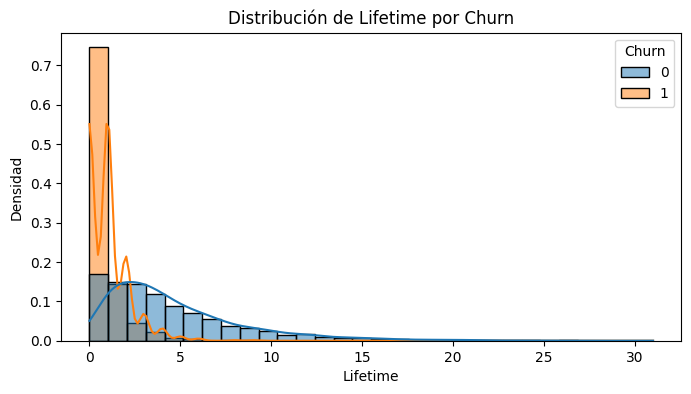

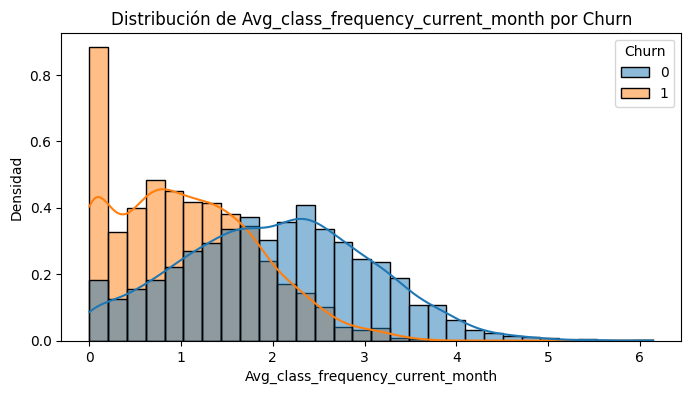

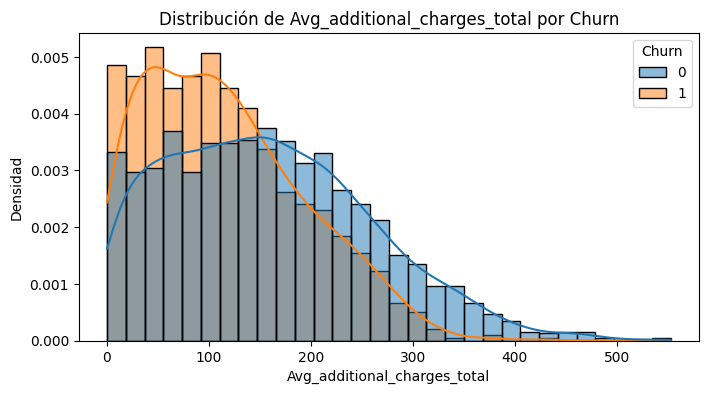

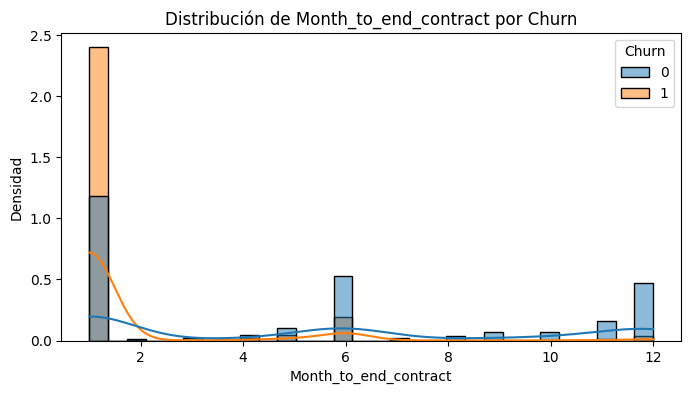

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'Lifetime',
    'Avg_class_frequency_current_month',
    'Avg_additional_charges_total',
    'Month_to_end_contract'
]

for feature in features:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=df,
        x=feature,
        hue='Churn',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False
    )
    plt.title(f'Distribución de {feature} por Churn')
    plt.xlabel(feature)
    plt.ylabel('Densidad')
    plt.show()

Los histogramas muestran diferencias significativas entre las distribuciones de los clientes que cancelan y los que permanecen. En particular, la cancelación se concentra en clientes con una baja antigüedad y una frecuencia de visitas reducida en el mes actual. Estas diferencias visuales confirman que la actividad reciente y la etapa temprana del ciclo de vida del cliente son factores clave asociados a la pérdida.

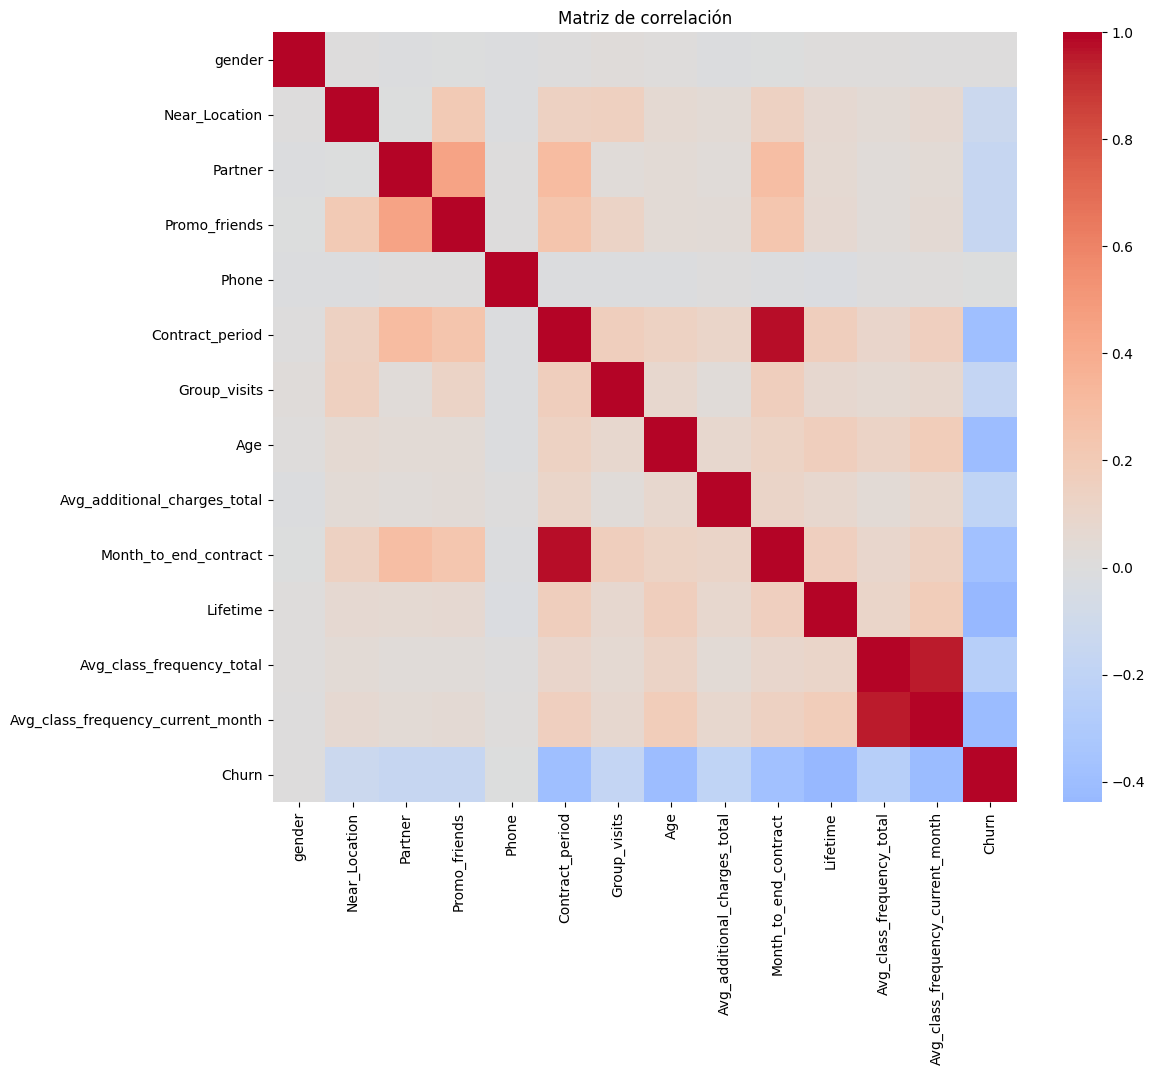

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)
plt.title('Matriz de correlación')
plt.show()

La matriz de correlación muestra que la cancelación está negativamente asociada con la frecuencia de visitas, el tiempo de permanencia y los meses restantes de contrato. La edad también presenta una correlación negativa moderada con la cancelación, lo que indica que los clientes más jóvenes tienden a abandonar con mayor frecuencia. No se observan correlaciones fuertes entre variables demográficas simples como el género y la cancelación.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien mostrada la matriz de correlación! Solo ten en cuenta que no siempre correlación significa causalidad, puede que en algunos casos tengas variables altamente correlacionadas pero no necesariamente son causa una de la otra

# Paso 3. Construir un modelo para predecir la cancelación de usuarios

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score


## Separar variables

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']


## División train / validación

In [ ]:

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


## Estandarizar

In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)



## Regresion Logistica

In [ ]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

## Métricas regresión logística

In [ ]:
y_pred_lr = log_reg.predict(X_valid_scaled)

accuracy_lr = accuracy_score(y_valid, y_pred_lr)
precision_lr = precision_score(y_valid, y_pred_lr)
recall_lr = recall_score(y_valid, y_pred_lr)

accuracy_lr, precision_lr, recall_lr


(0.91625, 0.8729281767955801, 0.7821782178217822)

## Random Forest

In [ ]:

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Métricas Random Forest

In [ ]:

y_pred_rf = rf.predict(X_valid)

accuracy_rf = accuracy_score(y_valid, y_pred_rf)
precision_rf = precision_score(y_valid, y_pred_rf)
recall_rf = recall_score(y_valid, y_pred_rf)

accuracy_rf, precision_rf, recall_rf



(0.91, 0.8494623655913979, 0.7821782178217822)

## Comparación

In [ ]:
pd.DataFrame({
    'Modelo': ['Regresión logística', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf]
})

,Modelo,Accuracy,Precision,Recall
0,Regresión logística,0.91625,0.872928,0.782178
1,Random Forest,0.91000,0.849462,0.782178


Se entrenaron dos modelos de clasificación: regresión logística y Random Forest. Ambos modelos mostraron un rendimiento similar en términos de recall, identificando aproximadamente el 78% de los clientes que cancelan. Sin embargo, la regresión logística obtuvo una mayor exactitud y precisión, por lo que se selecciona como el modelo más adecuado para este problema, además de ofrecer una mayor interpretabilidad de los resultados.

# Paso 4. Crear clústeres de usuarios/as

In [ ]:
X_cluster = df.drop('Churn', axis=1)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


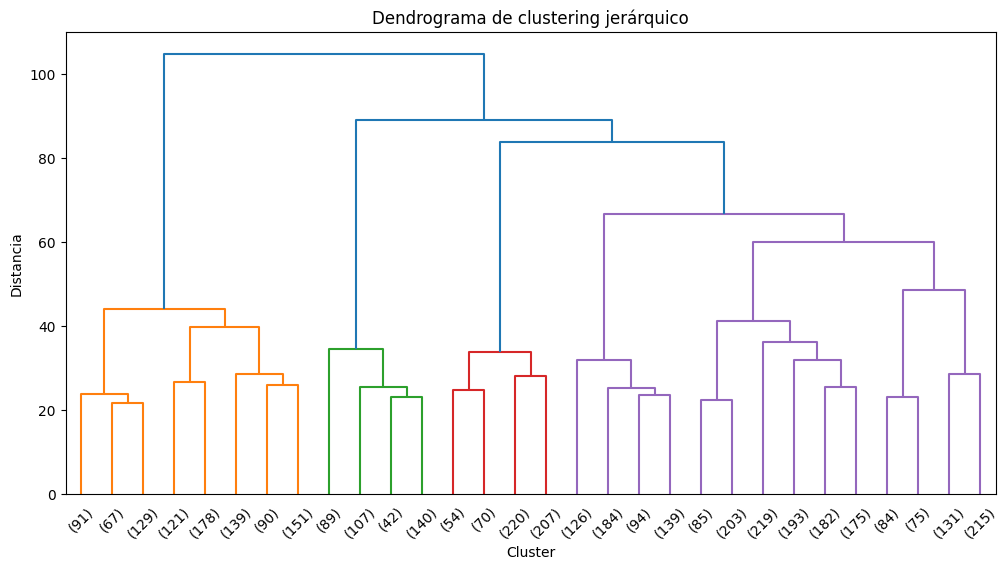

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_cluster_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Dendrograma de clustering jerárquico')
plt.xlabel('Cluster')
plt.ylabel('Distancia')
plt.show()


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_cluster_scaled)

df['cluster'] = clusters


In [ ]:
cluster_means = df.groupby('cluster').mean()
cluster_means


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


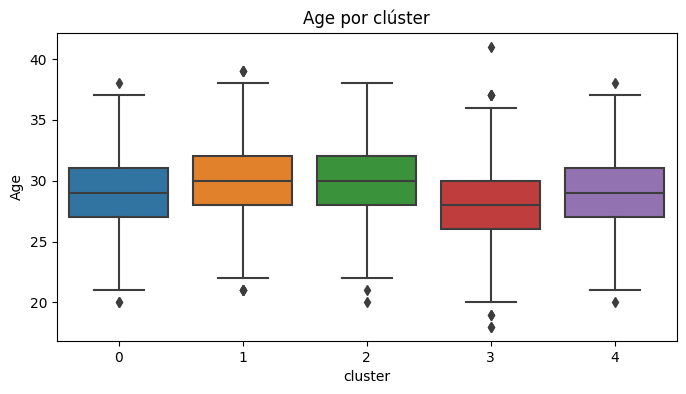

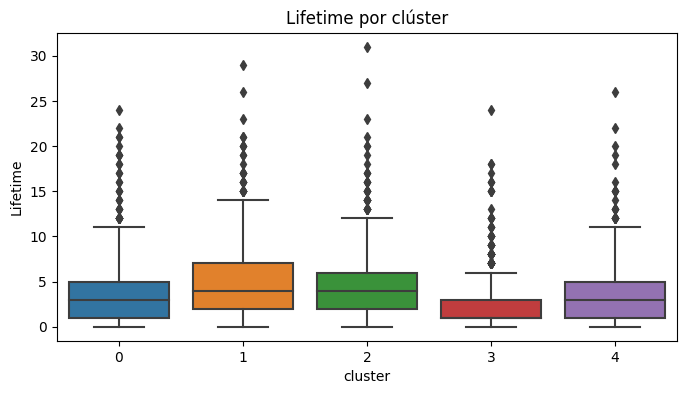

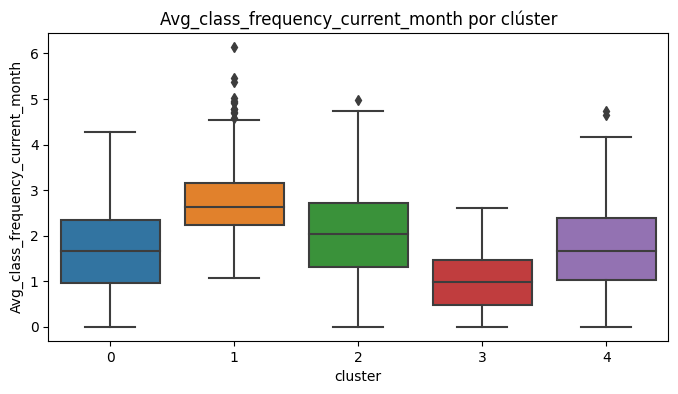

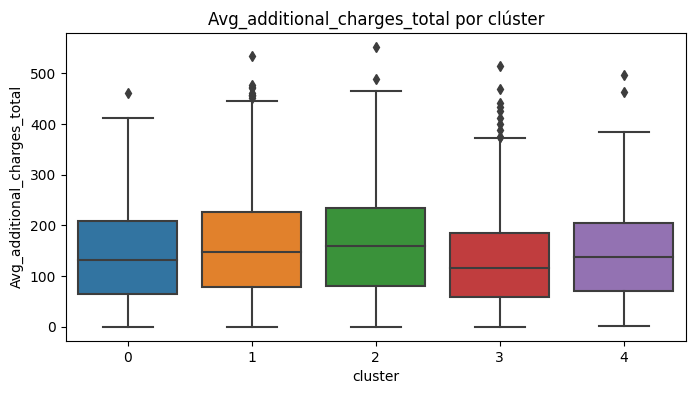

In [ ]:
import seaborn as sns

features = [
    'Age',
    'Lifetime',
    'Avg_class_frequency_current_month',
    'Avg_additional_charges_total'
]

for feature in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='cluster', y=feature, data=df)
    plt.title(f'{feature} por clúster')
    plt.show()


In [ ]:
churn_by_cluster = df.groupby('cluster')['Churn'].mean()
churn_by_cluster


cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64

La tasa de cancelación varía significativamente entre clústeres. El clúster 3 presenta una tasa de churn extremadamente alta (57%), caracterizada por bajo nivel de engagement. En contraste, los clústeres 1 y 2 muestran tasas de cancelación bajas, especialmente el clúster 2 (2%), cuyos usuarios presentan mayor frecuencia de asistencia, mayor lifetime y mayor gasto adicional. Esto confirma que el engagement es el principal factor asociado a la retención.

# Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes

Conclusiones

1. El nivel de interacción del cliente es el factor clave en la cancelación
Los usuarios con menor frecuencia de asistencia, menor gasto adicional y menor antigüedad presentan las tasas más altas de cancelación. Esto sugiere que el compromiso con el servicio es determinante para la retención.

2. La segmentación revela grupos con comportamientos muy distintos
El clustering permitió identificar tanto clientes altamente leales (con tasas de churn muy bajas) como grupos de alto riesgo, donde más de la mitad de los usuarios cancelan. Esto demuestra que tratar a todos los clientes de la misma manera no es una estrategia eficiente.

3. La edad y el uso del servicio están relacionados con la cancelación
Los usuarios más jóvenes y con menor frecuencia de uso tienden a abandonar el servicio con mayor frecuencia que aquellos con mayor edad y mayor participación.

Recomendaciones

1. Implementar acciones tempranas de retención para clientes de alto riesgo
Identificar a los usuarios con baja frecuencia de clases y corta permanencia (por ejemplo, los clústeres con mayor churn) y aplicar campañas de retención tempranas, como recordatorios personalizados, promociones de reactivación o clases de prueba gratuitas.

2. Fortalecer la fidelización de clientes leales
Para los clústeres con baja tasa de cancelación, se recomienda reforzar su vínculo con la marca mediante programas de referidos, beneficios por antigüedad y acceso exclusivo a promociones.

3. Incrementar el engagement como objetivo principal de negocio
Diseñar estrategias que fomenten una mayor asistencia y uso del servicio, como paquetes de clases, retos mensuales, planes personalizados o recomendaciones basadas en el comportamiento del cliente.

4. Utilizar modelos predictivos como herramienta operativa
Integrar los modelos de predicción de churn en los procesos del negocio para detectar usuarios con alto riesgo de cancelación y activar acciones preventivas de manera proactiva.